# Ultrasimplified Load Suite

A stripped-down version of `load_suite_v2`. Five plain classes, almost no inheritance:

1. **`Measurement`** – loads the csv and picks out "load" or "elongation" vs time.
2. **`PlotConfig`** – a dataclass holding plot styling options (colors, sizes, scales...).
3. **`Plotter`** – draws one series and styles the axes, using whatever `PlotConfig` says.
4. **`ThreeSigmaLimits`** – works out mean ± 3·std ("three-sigma") pass/fail bands per material.
5. **`LoadSuiteDashboard`** – the "frontend": the only class you actually call. It wires the
   other four together and can (a) plot a single DUT, (b) plot a comparison of all DUTs, and
   (c) print/plot a one-shot summary dashboard.


In [ ]:
# --- imports + load the raw csv once, cleaned up so every class below can reuse it ---
from dataclasses import dataclass
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

raw_data = pd.read_csv('data/tensile_load_time_raw.csv')

# tidy column names: "Load (kN)" -> "load_kn", so we can type them without quotes/spaces later
raw_data.columns = (
    raw_data.columns.str.strip().str.lower()
    .str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
)
# the csv spells each material inconsistently ("Steel-4140", "steel 4140", "Aluminum6061"...);
# normalize to one canonical spelling per material so the three-sigma grouping below is meaningful
raw_data['material'] = (
    raw_data['material'].str.strip().str.lower().str.replace('-', ' ', regex=False)
    .str.replace(r'([a-z])(\d)', r'\1 \2', regex=True)
    .str.title()
)

# pandas can infer these as text instead of numbers; force them to numeric so math (mean/std) works
for numeric_col in ['elapsed_time_s', 'load_kn', 'extension_mm']:
    raw_data[numeric_col] = pd.to_numeric(raw_data[numeric_col], errors='coerce')

raw_data.head()


,test_run_id,unit_id,material,test_date,machine_id,sample_thickness_mm,elapsed_time_s,load_kn,extension_mm,operator,sensor_status
0,TT-2026-001,UT-001,Steel 4140,2026-07-01,TT-01,4.48,0,0.00,-0.018,B. Chen,OK
1,TT-2026-001,UT-001,Steel 4140,2026-07-01,TT-01,4.48,10,18.70,0.233,B. Chen,OK
2,TT-2026-001,UT-001,Steel 4140,2026-07-01,TT-01,4.48,20,34.57,0.351,B. Chen,OK
3,TT-2026-001,UT-001,Steel 4140,2026-07-01,TT-01,4.48,30,49.34,0.596,B. Chen,OK
4,TT-2026-001,UT-001,Steel 4140,2026-07-01,TT-01,4.48,40,63.82,0.720,B. Chen,OK


### 1. `Measurement`
Picks which pair of columns to look at ("load" vs "elongation", both vs time) and keeps
only the clean rows. No inheritance, just one `if/else`-style lookup table.


In [2]:
class Measurement:
    """Wraps the raw dataframe and knows which columns count as "x" and "y" for a given type."""

    # measurement_type -> (x column, y column, x axis label, y axis label)
    # this one dict is the only thing that changes between "load" and "elongation"
    COLUMN_MAP = {
        "load": ("elapsed_time_s", "load_kn", "Elapsed Time (s)", "Load (kN)"),
        "elongation": ("elapsed_time_s", "extension_mm", "Elapsed Time (s)", "Elongation (mm)"),
    }

    def __init__(self, data: pd.DataFrame, measurement_type: str = "load"):
        self.measurement_type = measurement_type
        self.x_col, self.y_col, self.x_label, self.y_label = self.COLUMN_MAP[measurement_type]
        # drop any row missing the columns we actually need, so plots never choke on NaNs
        self.data = data.dropna(subset=[self.x_col, self.y_col, "unit_id", "material"]).copy()

    def for_unit(self, unit_id: str) -> pd.DataFrame:
        # rows for one DUT only, sorted so a line plot draws left-to-right in time
        return self.data[self.data["unit_id"] == unit_id].sort_values(self.x_col)

    def unit_ids(self) -> list[str]:
        return sorted(self.data["unit_id"].unique())


### 2. `PlotConfig`
Just a bag of styling options. A `@dataclass` gives us this for free (no `__init__` to write),
and every field has a default so you only override what you care about.


In [3]:
@dataclass
class PlotConfig:
    plot_kind: str = "line"  # "line", "scatter", or "line_scatter"
    figure_size: tuple[float, float] = (11, 6)
    color_map: str = "tab10"
    x_scale: str = "linear"
    y_scale: str = "linear"
    x_label: str | None = None  # None -> Plotter falls back to the Measurement's own label
    y_label: str | None = None
    title: str | None = None
    x_limits: tuple[float, float] | None = None
    y_limits: tuple[float, float] | None = None
    show_grid: bool = True
    line_width: float = 1.8
    marker_size: float = 18
    alpha: float = 0.9


### 3. `Plotter`
Everything that touches matplotlib lives here: drawing a series and styling the axes.
One class, no subclasses — `plot_kind` is just checked with `if`/`in` instead.


In [4]:
class Plotter:
    """Draws a single x/y series onto an Axes, and styles that Axes, using a PlotConfig."""

    def __init__(self, config: PlotConfig):
        self.config = config

    def plot_series(self, ax, x, y, label=None, color=None):
        # draw a line, a scatter, or both, depending on config.plot_kind
        c = self.config
        if c.plot_kind in ("line", "line_scatter"):
            ax.plot(x, y, linewidth=c.line_width, alpha=c.alpha, label=label, color=color)
        if c.plot_kind in ("scatter", "line_scatter"):
            # avoid a duplicate legend entry when we already labeled the line above
            scatter_label = label if c.plot_kind == "scatter" else None
            ax.scatter(x, y, s=c.marker_size, alpha=c.alpha, label=scatter_label, color=color)

    def style_axes(self, ax, x_label=None, y_label=None):
        # config's own label wins, otherwise fall back to whatever the caller passed in (the Measurement's label)
        c = self.config
        ax.set_xscale(c.x_scale)
        ax.set_yscale(c.y_scale)
        ax.set_xlabel(c.x_label or x_label or "")
        ax.set_ylabel(c.y_label or y_label or "")
        if c.title:
            ax.set_title(c.title)
        if c.x_limits:
            ax.set_xlim(c.x_limits)
        if c.y_limits:
            ax.set_ylim(c.y_limits)
        ax.grid(c.show_grid)


### 4. `ThreeSigmaLimits`
"Three-sigma" limits = mean ± 3×standard deviation. Any DUT whose peak value falls outside that
band is treated as an outlier/fail. We compute one band per `material`, from the peak (max) value
each DUT reaches.


In [5]:
class ThreeSigmaLimits:
    """Computes a (lower, upper) = mean +/- 3*std band per material, from each DUT's peak value."""

    def __init__(self, measurement: Measurement):
        self.measurement = measurement
        self.peaks = self._peak_per_unit()   # one row per DUT: its single peak value
        self.limits = self._compute()        # one row per material: mean/std/lower/upper

    def _peak_per_unit(self) -> pd.DataFrame:
        y = self.measurement.y_col
        data = self.measurement.data
        # idxmax gives the row index of the highest y value within each unit_id group
        peak_row_indexes = data.groupby("unit_id")[y].idxmax()
        return data.loc[peak_row_indexes, ["unit_id", "material", y]]

    def _compute(self) -> pd.DataFrame:
        y = self.measurement.y_col
        stats = self.peaks.groupby("material")[y].agg(["mean", "std"]).reset_index()
        stats["lower_limit"] = stats["mean"] - 3 * stats["std"]
        stats["upper_limit"] = stats["mean"] + 3 * stats["std"]
        return stats

    def for_material(self, material: str) -> tuple[float, float]:
        # returns (lower_limit, upper_limit) for that material
        row = self.limits[self.limits["material"] == material].iloc[0]
        return row["lower_limit"], row["upper_limit"]


### 5. `LoadSuiteDashboard` (the frontend)
This is the only class you actually talk to. It builds a `Measurement`, a `Plotter`, and a
`ThreeSigmaLimits` for you, then exposes three simple methods:

- `plot_unit(unit_id)` — (a) one DUT's load/elongation vs time, with its three-sigma band.
- `plot_comparison()` — (b) every DUT on one graph, drawn with seaborn.
- `show_dashboard()` — (c) the comparison plot plus a printed pass/fail summary.


In [6]:
class LoadSuiteDashboard:
    """Wires Measurement + Plotter + ThreeSigmaLimits together behind three plotting methods."""

    def __init__(self, data: pd.DataFrame, measurement_type: str = "load", plot_config: PlotConfig | None = None):
        self.measurement = Measurement(data, measurement_type)
        self.config = plot_config or PlotConfig()
        self.plotter = Plotter(self.config)
        self.limits = ThreeSigmaLimits(self.measurement)

    def _material_of(self, unit_id: str) -> str:
        # every row for a DUT has the same material, so just grab the first one
        return self.measurement.for_unit(unit_id)["material"].iloc[0]

    def plot_unit(self, unit_id: str, ax=None):
        # (a) individual DUT graph, with red dashed three-sigma limit lines overlaid
        ax = ax or plt.subplots(figsize=self.config.figure_size)[1]
        unit_data = self.measurement.for_unit(unit_id)
        self.plotter.plot_series(ax, unit_data[self.measurement.x_col], unit_data[self.measurement.y_col], label=unit_id)

        lower, upper = self.limits.for_material(self._material_of(unit_id))
        ax.axhline(upper, color="red", linestyle="--", linewidth=1, label="+3 sigma limit")
        ax.axhline(lower, color="red", linestyle="--", linewidth=1, label="-3 sigma limit")

        self.plotter.style_axes(ax, self.measurement.x_label, self.measurement.y_label)
        ax.legend()
        return ax

    def plot_comparison(self, ax=None):
        # (b) every DUT overlaid on one graph; seaborn colors + labels each unit_id automatically
        ax = ax or plt.subplots(figsize=self.config.figure_size)[1]
        sns.lineplot(
            data=self.measurement.data, x=self.measurement.x_col, y=self.measurement.y_col,
            hue="unit_id", alpha=self.config.alpha, linewidth=self.config.line_width, ax=ax,
        )
        self.plotter.style_axes(ax, self.measurement.x_label, self.measurement.y_label)
        return ax

    def show_dashboard(self):
        # (c) comparison plot + a plain-text three-sigma pass/fail summary underneath it
        fig, ax = plt.subplots(figsize=self.config.figure_size)
        self.plot_comparison(ax)
        ax.set_title(f"{self.measurement.y_label} — all DUTs")
        plt.show()

        print(f"--- {self.measurement.y_label} three-sigma limits by material ---")
        for _, row in self.limits.limits.iterrows():
            print(f"  {row['material']}: {row['lower_limit']:.2f} to {row['upper_limit']:.2f}")

        print(f"\n--- peak {self.measurement.y_label} per DUT ---")
        for _, row in self.limits.peaks.iterrows():
            y = self.measurement.y_col
            lower, upper = self.limits.for_material(row["material"])
            status = "PASS" if lower <= row[y] <= upper else "FAIL"
            print(f"  {row['unit_id']} ({row['material']}): peak={row[y]:.2f} -> {status}")


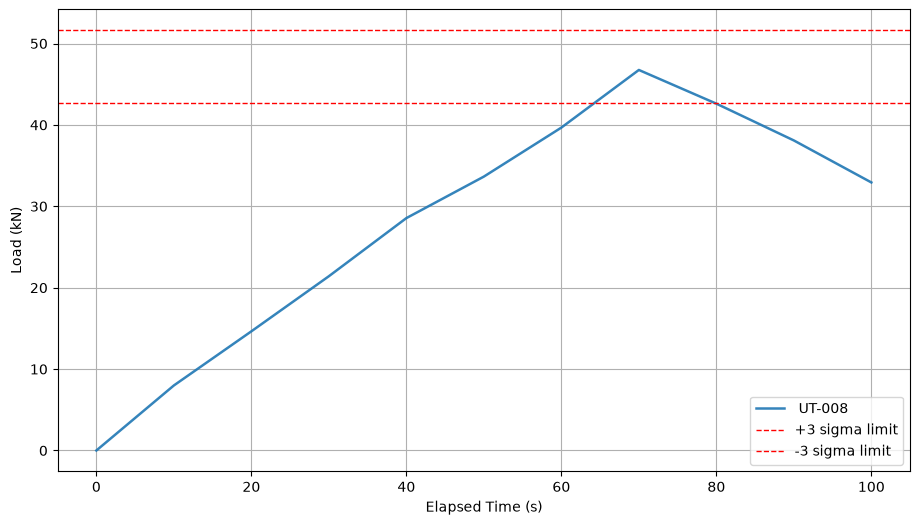

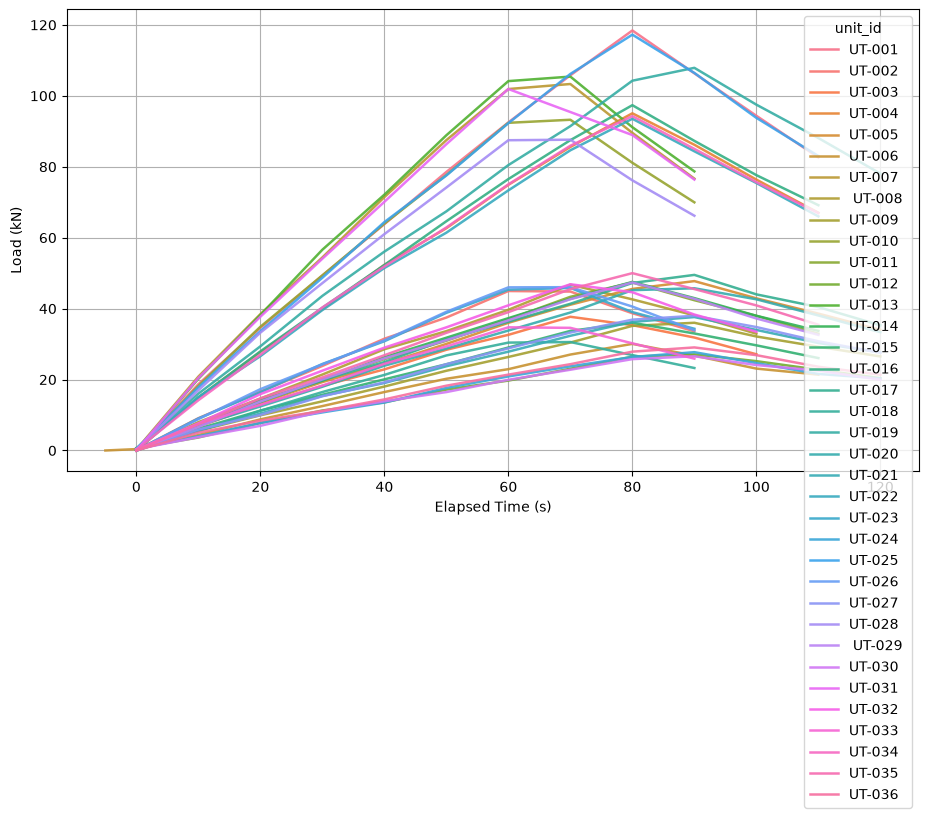

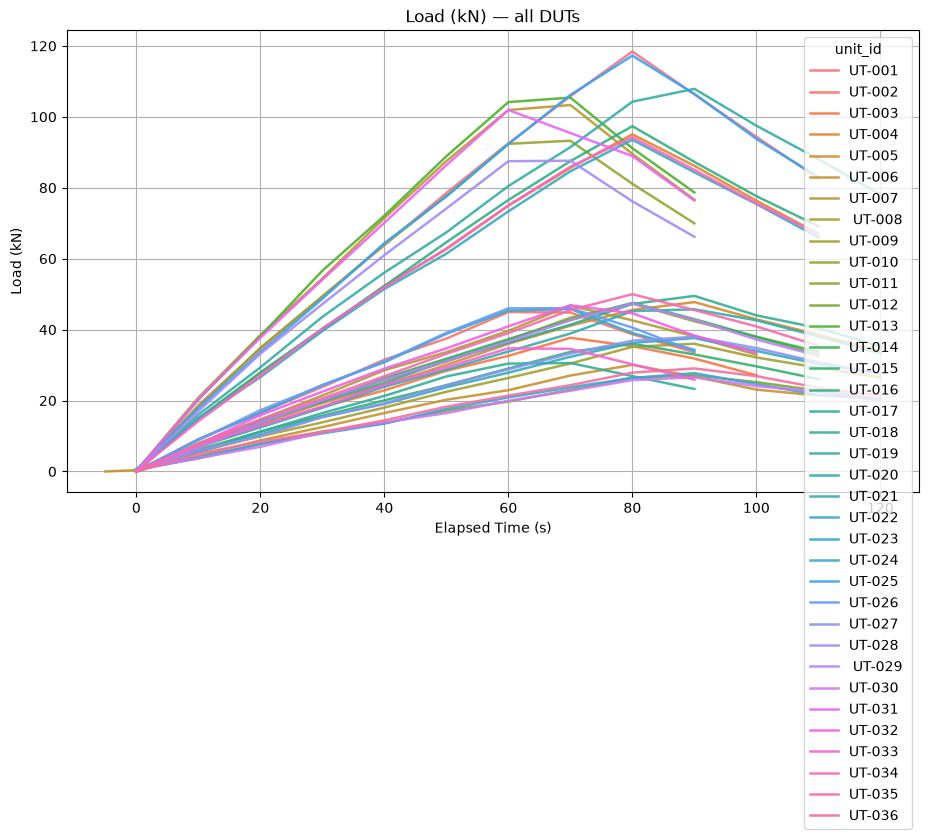

--- Load (kN) three-sigma limits by material ---
  Aluminum 6061: 42.69 to 51.60
  Copper C 110: 19.14 to 46.06
  Steel 4140: 72.27 to 130.28

--- peak Load (kN) per DUT ---
   UT-008  (Aluminum 6061): peak=46.75 -> PASS
   UT-029  (Aluminum 6061): peak=47.36 -> PASS
  UT-001 (Steel 4140): peak=118.42 -> PASS
  UT-002 (Aluminum 6061): peak=44.96 -> PASS
  UT-003 (Copper C 110): peak=37.70 -> PASS
  UT-004 (Steel 4140): peak=95.07 -> PASS
  UT-005 (Aluminum 6061): peak=47.76 -> PASS
  UT-006 (Copper C 110): peak=30.06 -> PASS
  UT-007 (Steel 4140): peak=103.33 -> PASS
  UT-009 (Copper C 110): peak=36.01 -> PASS
  UT-010 (Steel 4140): peak=93.25 -> PASS
  UT-011 (Aluminum 6061): peak=47.35 -> PASS
  UT-012 (Copper C 110): peak=27.11 -> PASS
  UT-013 (Steel 4140): peak=105.42 -> PASS
  UT-014 (Aluminum 6061): peak=47.53 -> PASS
  UT-015 (Copper C 110): peak=36.02 -> PASS
  UT-016 (Steel 4140): peak=97.36 -> PASS
  UT-017 (Aluminum 6061): peak=49.51 -> PASS
  UT-018 (Copper C 110): peak=30

In [13]:
# --- try it out ---
load_dashboard = LoadSuiteDashboard(raw_data, measurement_type="load")

# a) individual DUT plot
load_dashboard.plot_unit(load_dashboard.measurement.unit_ids()[0])
plt.show()

# b) comparison plot (all DUTs, seaborn)
load_dashboard.plot_comparison()
plt.show()

# c) overall dashboard: comparison plot + printed pass/fail summary
load_dashboard.show_dashboard()
